# Spread Locator: A Statistical Distribution Analysis Model

## Mathematics & Advanced Statistics

**Project:** Spread Locator  
**Dataset:** E-commerce Transaction Dataset

---

### Objective

To understand and apply statistical distribution concepts and transformations on e-commerce transaction data, including Bernoulli, Binomial, Poisson, Log-Normal, Power Law, Q-Q plots, Box-Cox transformation, Z-scores, PDF and CDF.

In [1]:
pip install pandas numpy scipy matplotlib seaborn openpyxl statsmodels


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import poisson, binom, norm, lognorm, pareto

print("All libraries imported successfully.")

All libraries imported successfully.


In [14]:
df = pd.read_excel("spread_locator_dataset.xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [16]:
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [17]:
df.describe()

,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


In [18]:
df.tail()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success
219,c7d958bb-62b5-43a8-bfb9-30edc213fa85,CUST8260,3105.52,2023-01-28,1,South,Fail


In [19]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 220
Number of Columns: 7


In [20]:
print(df.columns)

Index(['transaction_id', 'customer_id', 'transaction_amount',
       'transaction_date', 'transaction_count', 'region',
       'transaction_status'],
      dtype='object')


In [21]:
print(df.dtypes)

transaction_id                object
customer_id                   object
transaction_amount           float64
transaction_date      datetime64[ns]
transaction_count              int64
region                        object
transaction_status            object
dtype: object


In [22]:
print(df.isnull().sum())

transaction_id        0
customer_id           0
transaction_amount    0
transaction_date      0
transaction_count     0
region                0
transaction_status    0
dtype: int64


In [23]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [24]:
print("Duplicate Transaction IDs:",
      df["transaction_id"].duplicated().sum())

Duplicate Transaction IDs: 0


## Basic Statistical Summary

In [25]:
df.describe()

,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


In [26]:
amount = df["transaction_amount"]

print("Mean:", amount.mean())
print("Median:", amount.median())
print("Standard Deviation:", amount.std())
print("Minimum:", amount.min())
print("Maximum:", amount.max())

Mean: 3365.1924090909088
Median: 3077.715
Standard Deviation: 1985.7054091615962
Minimum: 804.42
Maximum: 20462.84


In [27]:
skewness = stats.skew(amount)

print("Skewness:", skewness)

Skewness: 3.730109977696717


### Transaction Amount Distribution

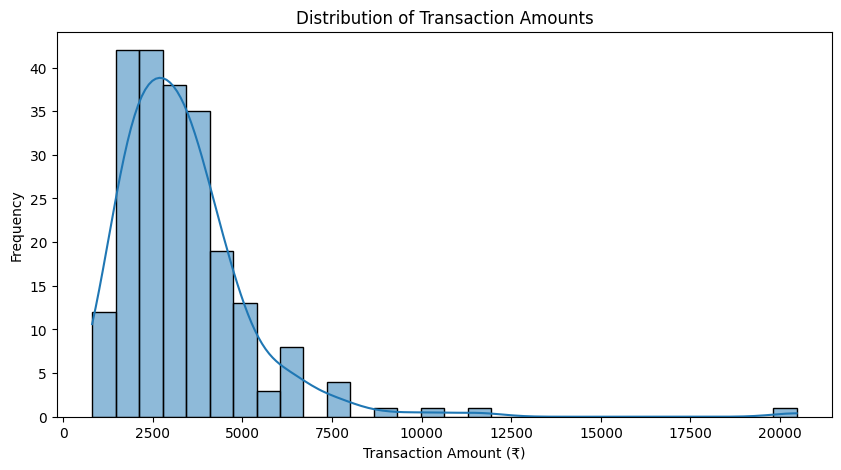

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["transaction_amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")

plt.savefig(
    "plots/transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# PART B — DATA ANALYSIS

## 1. Bernoulli Distribution

In [29]:
print(df["transaction_status"].value_counts())

transaction_status
Fail       122
Success     98
Name: count, dtype: int64


In [30]:
df["success"] = (
    df["transaction_status"] == "Success"
).astype(int)

df[["transaction_status", "success"]].head()

,transaction_status,success
0,Fail,0
1,Fail,0
2,Fail,0
3,Success,1
4,Success,1


In [31]:
p_success = df["success"].mean()

p_failure = 1 - p_success

print("Probability of Success:", p_success)
print("Probability of Failure:", p_failure)

Probability of Success: 0.44545454545454544
Probability of Failure: 0.5545454545454546


In [32]:
print("Success Rate:", p_success * 100, "%")
print("Failure Rate:", p_failure * 100, "%")

Success Rate: 44.54545454545455 %
Failure Rate: 55.45454545454545 %


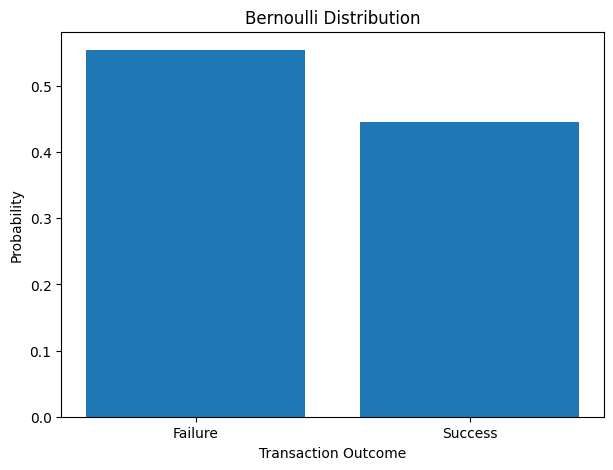

In [33]:
x = [0, 1]
probabilities = [p_failure, p_success]

plt.figure(figsize=(7, 5))

plt.bar(
    x,
    probabilities
)

plt.xticks(
    [0, 1],
    ["Failure", "Success"]
)

plt.xlabel("Transaction Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution")

plt.savefig(
    "plots/bernoulli_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The transaction status has two possible outcomes: Success and Failure. The observed probability of a successful transaction is approximately 44.55%, while the probability of failure is approximately 55.45%. Therefore, failures occur more frequently than successful transactions in this dataset.

## 2. Binomial Distribution

In [34]:
n = df["transaction_count"].max()

p_binomial = (
    df["transaction_count"].mean() / n
)

print("Number of Trials (n):", n)
print("Probability of Success (p):", p_binomial)

Number of Trials (n): 9
Probability of Success (p): 0.31717171717171716


In [35]:
x = np.arange(0, n + 1)

binomial_prob = binom.pmf(
    x,
    n,
    p_binomial
)

print("Binomial Probabilities:")
print(binomial_prob)

Binomial Probabilities:
[3.22703378e-02 1.34905288e-01 2.50652429e-01 2.71663727e-01
 1.89280496e-01 8.79202305e-02 2.72257913e-02 5.41984264e-03
 6.29375218e-04 3.24825474e-05]


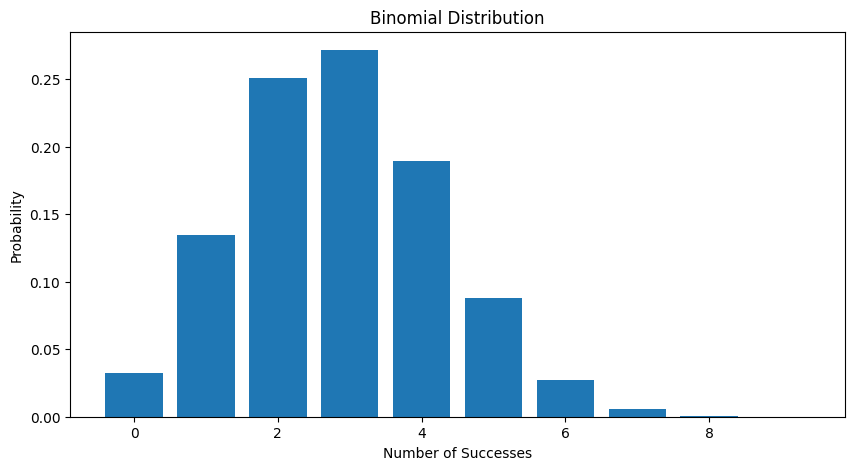

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(
    x,
    binomial_prob
)

plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.title("Binomial Distribution")

plt.savefig(
    "plots/binomial_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Binomial distribution is used to model the number of successes in a fixed number of trials. For practical demonstration, 9 trials were used based on the maximum observed transaction count, and the success probability was estimated from the mean transaction count.

This is an illustrative Binomial model because the dataset does not explicitly define a fixed number of independent weekly trials.

## 3. Poisson Distribution

In [37]:
df["date"] = df["transaction_date"].dt.date

df[["transaction_date", "date"]].head()

,transaction_date,date
0,2023-01-26,2023-01-26
1,2023-01-28,2023-01-28
2,2023-01-28,2023-01-28
3,2023-01-18,2023-01-18
4,2023-01-04,2023-01-04


In [38]:
daily_transactions = df.groupby("date").size()

print(daily_transactions)

date
2023-01-01     6
2023-01-02    12
2023-01-03    10
2023-01-04     7
2023-01-05     9
2023-01-06     6
2023-01-07     7
2023-01-08     5
2023-01-09    10
2023-01-10     8
2023-01-11     6
2023-01-12     4
2023-01-13     5
2023-01-14     6
2023-01-15     5
2023-01-16     5
2023-01-17     7
2023-01-18    12
2023-01-19     8
2023-01-20     6
2023-01-21     6
2023-01-22     8
2023-01-23     7
2023-01-24     5
2023-01-25     3
2023-01-26     6
2023-01-27     5
2023-01-28    10
2023-01-29    10
2023-01-30    10
2023-01-31     6
dtype: int64


In [39]:
print("Number of Days:", len(daily_transactions))
print("Minimum Daily Transactions:",
      daily_transactions.min())
print("Maximum Daily Transactions:",
      daily_transactions.max())
print("Average Daily Transactions:",
      daily_transactions.mean())

Number of Days: 31
Minimum Daily Transactions: 3
Maximum Daily Transactions: 12
Average Daily Transactions: 7.096774193548387


In [40]:
lambda_poisson = daily_transactions.mean()

print("Lambda (λ):", lambda_poisson)

Lambda (λ): 7.096774193548387


In [41]:
prob_10 = poisson.pmf(
    10,
    lambda_poisson
)

print(
    "Probability of exactly 10 transactions:",
    prob_10
)

print(
    "Percentage:",
    prob_10 * 100,
    "%"
)

Probability of exactly 10 transactions: 0.073919150198164
Percentage: 7.3919150198164 %


NameError: name 'x_poisson' is not defined

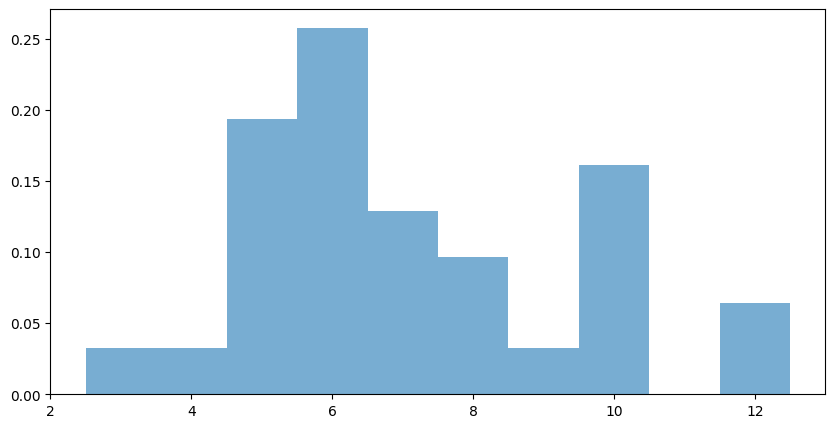

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(
    daily_transactions,
    bins=np.arange(
        daily_transactions.min() - 0.5,
        daily_transactions.max() + 1.5,
        1
    ),
    density=True,
    alpha=0.6,
    label="Observed Data"
)

plt.plot(
    x_poisson,
    poisson_prob,
    marker="o",
    label="Poisson PMF"
)

plt.xlabel("Transactions per Day")
plt.ylabel("Probability")
plt.title("Observed Daily Transactions vs Poisson Distribution")

plt.legend()

plt.savefig(
    "plots/observed_vs_poisson.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

 ### Interpretation

The dataset contains 31 days of transaction records. The average number of transactions per day is approximately 7.10. Using this value as the Poisson parameter λ, the probability of observing exactly 10 transactions on a day is approximately 7.39%.

The Poisson distribution provides a useful model for transaction event counts occurring over a fixed time interval.

## 4. Log-Normal Distribution

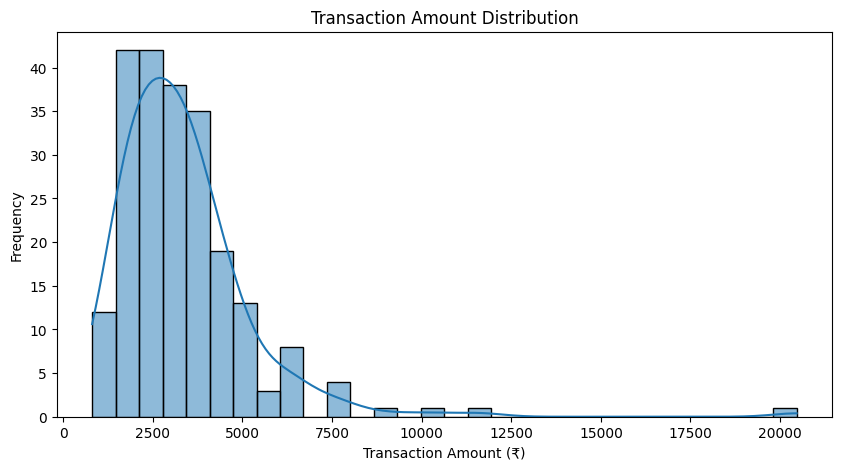

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    amount,
    bins=30,
    kde=True
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")

plt.show()

In [44]:
shape, loc, scale = stats.lognorm.fit(
    amount,
    floc=0
)

print("Shape:", shape)
print("Location:", loc)
print("Scale:", scale)

Shape: 0.4749178350151927
Location: 0
Scale: 2983.1591334067753


In [45]:
x_amount = np.linspace(
    amount.min(),
    amount.max(),
    500
)

lognormal_pdf = stats.lognorm.pdf(
    x_amount,
    shape,
    loc=loc,
    scale=scale
)

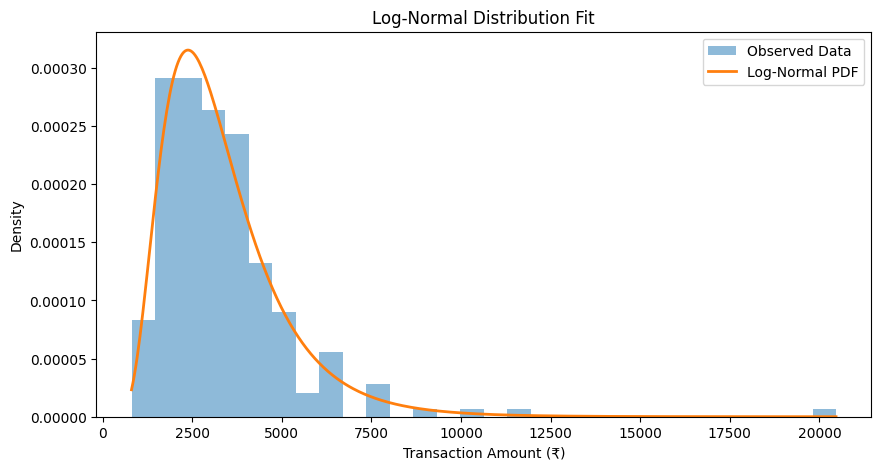

In [46]:
plt.figure(figsize=(10, 5))

plt.hist(
    amount,
    bins=30,
    density=True,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_amount,
    lognormal_pdf,
    linewidth=2,
    label="Log-Normal PDF"
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.title("Log-Normal Distribution Fit")

plt.legend()

plt.savefig(
    "plots/lognormal_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Power Law Distribution

In [47]:
power_shape, power_loc, power_scale = stats.pareto.fit(
    amount,
    floc=0
)

print("Power Law Shape:", power_shape)
print("Location:", power_loc)
print("Scale:", power_scale)

Power Law Shape: 0.7629996393449987
Location: 0
Scale: 804.42


In [48]:
power_pdf = stats.pareto.pdf(
    x_amount,
    power_shape,
    loc=power_loc,
    scale=power_scale
)

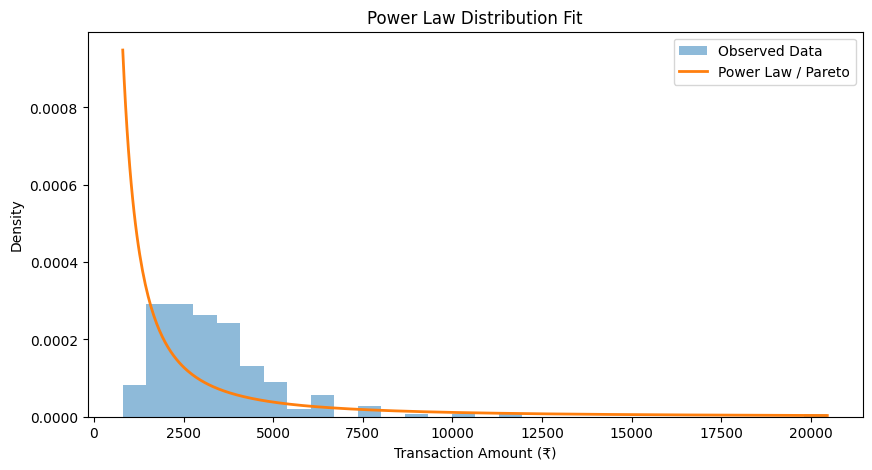

In [49]:
plt.figure(figsize=(10, 5))

plt.hist(
    amount,
    bins=30,
    density=True,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_amount,
    power_pdf,
    linewidth=2,
    label="Power Law / Pareto"
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.title("Power Law Distribution Fit")

plt.legend()

plt.savefig(
    "plots/powerlaw_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

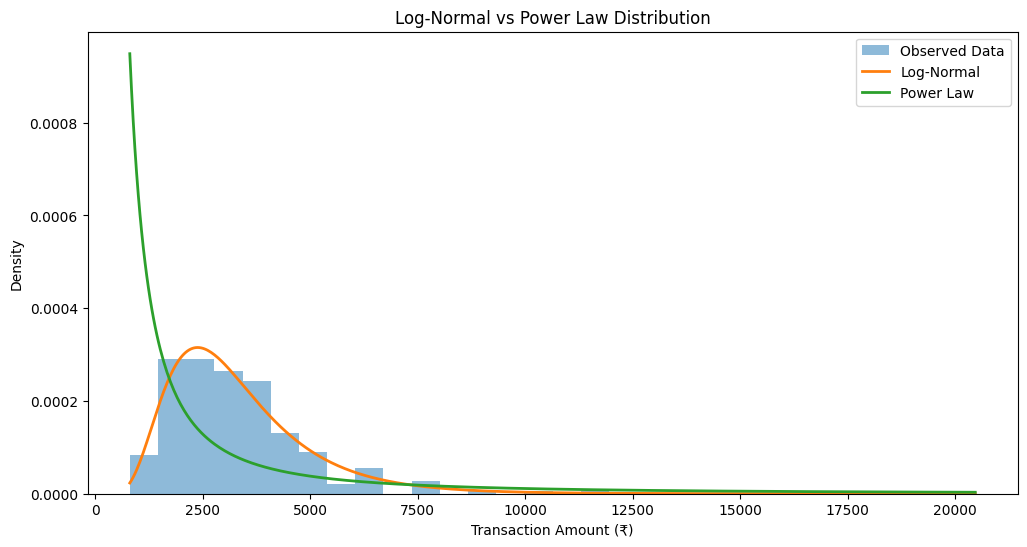

In [50]:
plt.figure(figsize=(12, 6))

plt.hist(
    amount,
    bins=30,
    density=True,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_amount,
    lognormal_pdf,
    linewidth=2,
    label="Log-Normal"
)

plt.plot(
    x_amount,
    power_pdf,
    linewidth=2,
    label="Power Law"
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.title("Log-Normal vs Power Law Distribution")

plt.legend()

plt.savefig(
    "plots/lognormal_vs_powerlaw.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Q-Q Plot and Normality Testing

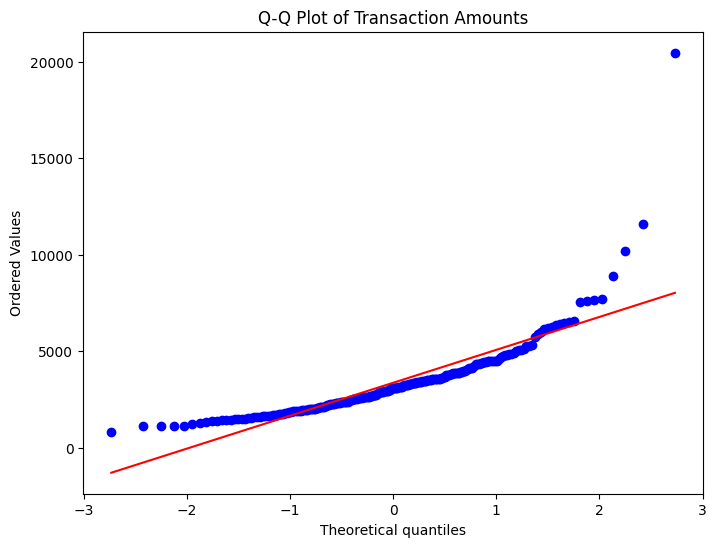

In [51]:
plt.figure(figsize=(8, 6))

stats.probplot(
    amount,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot of Transaction Amounts"
)

plt.savefig(
    "plots/qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
shapiro_stat, shapiro_p = stats.shapiro(
    amount
)

print("Shapiro-Wilk Statistic:",
      shapiro_stat)

print("p-value:",
      shapiro_p)

Shapiro-Wilk Statistic: 0.7360905663247675
p-value: 1.9104194773842295e-18


### Interpretation

The Q-Q plot shows substantial deviation of the observed transaction amounts from the theoretical normal distribution, especially in the tails.

The Shapiro-Wilk test produces a p-value far below 0.05. Therefore, the null hypothesis of normality is rejected. The transaction amounts are not normally distributed.

## 7. Box-Cox Transformation

In [53]:
transformed_amount, lambda_boxcox = stats.boxcox(
    amount
)

print("Box-Cox Lambda:",
      lambda_boxcox)

Box-Cox Lambda: -0.18083390743966327


In [54]:
original_skewness = stats.skew(
    amount
)

transformed_skewness = stats.skew(
    transformed_amount
)

print(
    "Original Skewness:",
    original_skewness
)

print(
    "Transformed Skewness:",
    transformed_skewness
)

Original Skewness: 3.730109977696717
Transformed Skewness: -0.010599306471364936


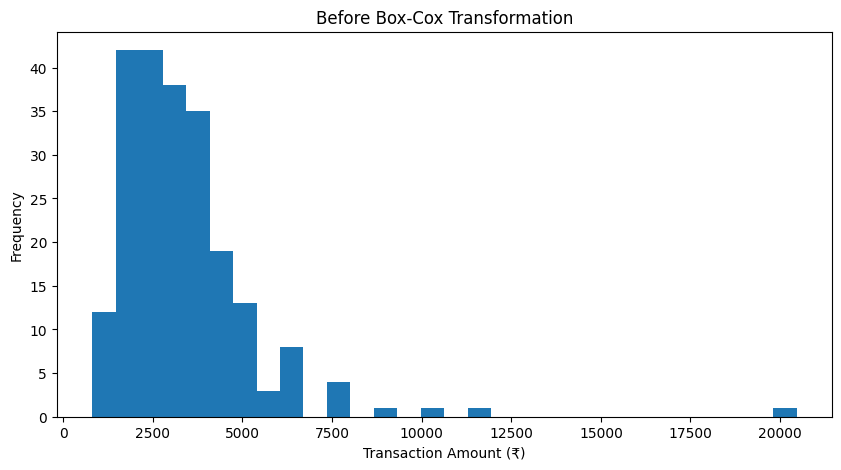

In [55]:
plt.figure(figsize=(10, 5))

plt.hist(
    amount,
    bins=30
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Frequency")
plt.title("Before Box-Cox Transformation")

plt.savefig(
    "plots/before_boxcox.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

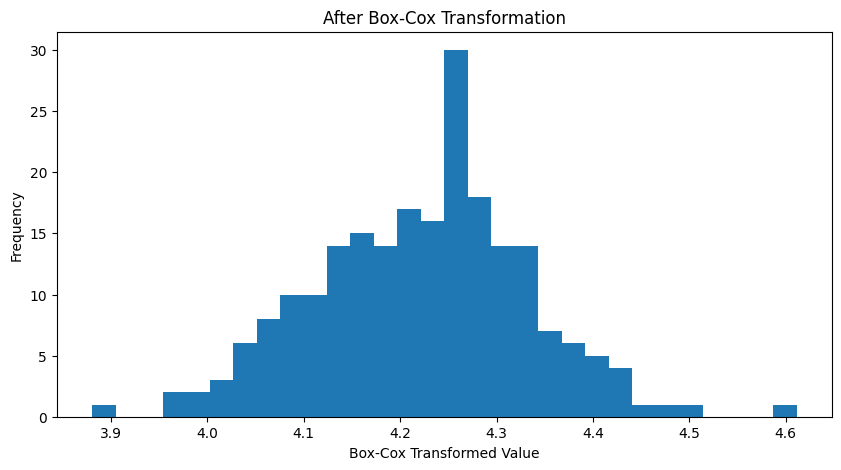

In [56]:
plt.figure(figsize=(10, 5))

plt.hist(
    transformed_amount,
    bins=30
)

plt.xlabel("Box-Cox Transformed Value")
plt.ylabel("Frequency")
plt.title("After Box-Cox Transformation")

plt.savefig(
    "plots/after_boxcox.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The original transaction amount distribution is strongly right-skewed, with a skewness of approximately 3.73. After applying the Box-Cox transformation, the skewness decreases to approximately -0.01. This indicates that the transformation substantially improves the symmetry of the data and reduces the effect of extreme values.

## 8. Z-Score Analysis

In [57]:
df["z_score"] = stats.zscore(
    df["transaction_amount"]
)

df[
    [
        "transaction_amount",
        "z_score"
    ]
].head(10)

,transaction_amount,z_score
0,3821.34,0.230240
1,2781.84,-0.294446
2,4120.97,0.381477
3,6383.78,1.523626
4,2651.61,-0.360179
5,2651.63,-0.360169
6,6565.65,1.615424
7,4375.24,0.509819
8,2357.28,-0.508742
9,3909.95,0.274965


In [58]:
mean_amount = amount.mean()
std_amount = amount.std()

z_5000 = (
    5000 - mean_amount
) / std_amount

print("Mean:", mean_amount)
print("Standard Deviation:", std_amount)
print("Z-score for ₹5000:", z_5000)

Mean: 3365.1924090909088
Standard Deviation: 1985.7054091615962
Z-score for ₹5000: 0.8232880785671723


### Interpretation

A transaction amount of ₹5000 has a Z-score of approximately 0.823. This means that ₹5000 is approximately 0.82 standard deviations above the sample mean transaction amount.

In [59]:
normal_probability_above_5000 = (
    1 - stats.norm.cdf(z_5000)
)

print(
    "Normal-model probability of amount > ₹5000:",
    normal_probability_above_5000
)

print(
    "Percentage:",
    normal_probability_above_5000 * 100,
    "%"
)

Normal-model probability of amount > ₹5000: 0.20517209567554384
Percentage: 20.517209567554385 %


In [60]:
actual_probability_above_5000 = (
    amount > 5000
).mean()

print(
    "Actual proportion above ₹5000:",
    actual_probability_above_5000
)

print(
    "Actual percentage:",
    actual_probability_above_5000 * 100,
    "%"
)

Actual proportion above ₹5000: 0.11363636363636363
Actual percentage: 11.363636363636363 %


### Important Observation

The normal-model estimate of the probability of a transaction amount exceeding ₹5000 is approximately 20.52%, whereas the actual proportion observed in the dataset is approximately 11.36%.

This difference occurs because the transaction amount data is strongly right-skewed and does not follow a normal distribution. Therefore, the normal approximation should not be treated as the preferred model for transaction amounts.

## 9. Probability Density Function (PDF)

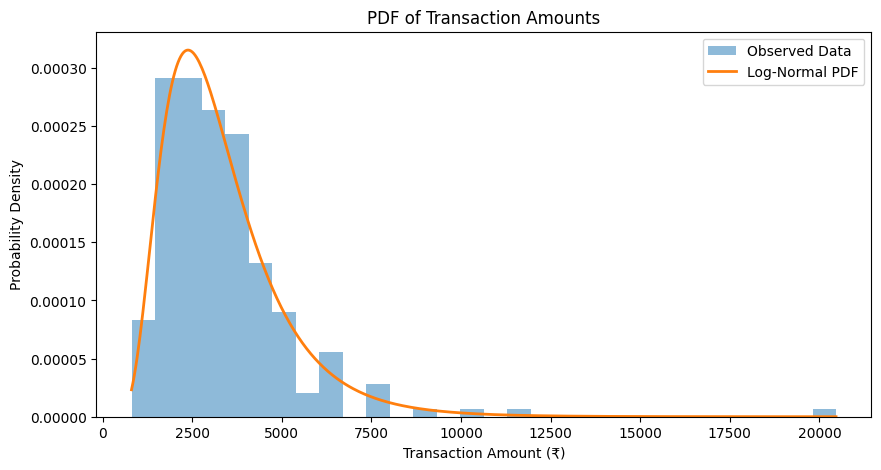

In [61]:
plt.figure(figsize=(10, 5))

plt.hist(
    amount,
    bins=30,
    density=True,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_amount,
    lognormal_pdf,
    linewidth=2,
    label="Log-Normal PDF"
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Probability Density")
plt.title("PDF of Transaction Amounts")

plt.legend()

plt.savefig(
    "plots/transaction_amount_pdf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Probability Density Function shows the relative density of transaction amounts across different values. The fitted Log-Normal PDF follows the general shape of the observed transaction amount distribution and reflects its strong right-skewed nature.

## 10. Cumulative Distribution Function (CDF)

lognormal_cdf = stats.lognorm.cdf(
    x_amount,
    shape,
    loc=loc,
    scale=scale
)

plt.figure(figsize=(10, 5))

plt.plot(
    x_amount,
    lognormal_cdf,
    linewidth=2
)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Transaction Amounts")

plt.grid()

plt.savefig(
    "plots/transaction_amount_cdf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
probability_below_5000 = stats.lognorm.cdf(
    5000,
    shape,
    loc=loc,
    scale=scale
)

probability_above_5000_lognormal = (
    1 - probability_below_5000
)

print(
    "Log-Normal P(X <= 5000):",
    probability_below_5000
)

print(
    "Log-Normal P(X > 5000):",
    probability_above_5000_lognormal
)

Log-Normal P(X <= 5000): 0.8615836409266394
Log-Normal P(X > 5000): 0.13841635907336058


### Interpretation

The CDF gives the cumulative probability that a transaction amount is less than or equal to a given value. Based on the fitted Log-Normal model, the estimated probability of a transaction amount exceeding ₹5000 is approximately 13.84%.

In [65]:
lognormal_loglik = np.sum(
    stats.lognorm.logpdf(
        amount,
        shape,
        loc=loc,
        scale=scale
    )
)

power_loglik = np.sum(
    stats.pareto.logpdf(
        amount,
        power_shape,
        loc=power_loc,
        scale=power_scale
    )
)

lognormal_aic = 4 - 2 * lognormal_loglik
power_aic = 4 - 2 * power_loglik

print("Log-Normal AIC:", lognormal_aic)
print("Power Law AIC:", power_aic)

Log-Normal AIC: 3821.027805464873
Power Law AIC: 4083.3437741043394


### Model Comparison

AIC is used to compare statistical models, where a lower AIC indicates a better balance between model fit and model complexity.

The Log-Normal model has an AIC of approximately 3821.03, while the Power Law/Pareto model has an AIC of approximately 4083.34. Therefore, the Log-Normal model provides the better fit among these two models for the transaction amount data.

In [66]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Records",
        "Success Probability",
        "Failure Probability",
        "Average Daily Transactions",
        "Probability of Exactly 10 Transactions",
        "Mean Transaction Amount",
        "Median Transaction Amount",
        "Standard Deviation",
        "Skewness",
        "Z-score for ₹5000",
        "Normal Probability > ₹5000",
        "Actual Proportion > ₹5000",
        "Log-Normal Probability > ₹5000",
        "Box-Cox Lambda",
        "Original Skewness",
        "Transformed Skewness",
        "Log-Normal AIC",
        "Power Law AIC"
    ],
    
    "Value": [
        len(df),
        p_success,
        p_failure,
        lambda_poisson,
        prob_10,
        mean_amount,
        amount.median(),
        std_amount,
        original_skewness,
        z_5000,
        normal_probability_above_5000,
        actual_probability_above_5000,
        probability_above_5000_lognormal,
        lambda_boxcox,
        original_skewness,
        transformed_skewness,
        lognormal_aic,
        power_aic
    ]
})

summary

,Metric,Value
0,Number of Records,220.000000
1,Success Probability,0.445455
2,Failure Probability,0.554545
3,Average Daily Transactions,7.096774
4,Probability of Exactly 10 Transactions,0.073919
5,Mean Transaction Amount,3365.192409
6,Median Transaction Amount,3077.715000
7,Standard Deviation,1985.705409
8,Skewness,3.730110
9,Z-score for ₹5000,0.823288


# Final Conclusion

The Spread Locator analysis was performed on 220 e-commerce transaction records.

The transaction status was analyzed using the Bernoulli distribution. The probability of a successful transaction was approximately 44.55%, while the probability of failure was approximately 55.45%.

The daily transaction count was modeled using a Poisson distribution. The average number of transactions per day was approximately 7.10, and the probability of exactly 10 transactions on a day was approximately 7.39%.

The transaction amount data was found to be strongly right-skewed, with a skewness of approximately 3.73. The Q-Q plot and Shapiro-Wilk test showed that the transaction amounts do not follow a normal distribution.

A Box-Cox transformation reduced the skewness from approximately 3.73 to approximately -0.01, showing that the transformation substantially improved the symmetry of the data.

The transaction amounts were also modeled using Log-Normal and Power Law/Pareto distributions. Based on AIC comparison, the Log-Normal model provided a better fit than the Power Law model.

For ₹5000, the calculated Z-score was approximately 0.823. A normal-distribution approximation gave a probability of approximately 20.52% for transaction amounts exceeding ₹5000. However, because the original data is not normally distributed, this value should only be treated as an approximation. The actual observed proportion above ₹5000 was approximately 11.36%, while the fitted Log-Normal model estimated approximately 13.84%.

Overall, the analysis indicates that the transaction amount data is better represented by a right-skewed Log-Normal distribution rather than a Normal distribution. This information can help an e-commerce platform understand transaction behavior, identify unusually large transactions, and improve probability-based business decisions.

1. Q-Q Plot

A Q-Q (Quantile-Quantile) plot compares the quantiles of observed data with the quantiles of a theoretical distribution. If the points approximately follow a straight diagonal line, the data may follow the selected theoretical distribution. Large deviations indicate that the data may not follow that distribution.

2. Statistical Distribution

A statistical distribution describes how the values of a variable are distributed and how frequently different values occur. It helps us understand the probability of different outcomes. Common distributions include Bernoulli, Binomial, Poisson, Normal and Log-Normal distributions.

3. Bernoulli

Bernoulli distribution models a single experiment with only two possible outcomes. These outcomes are generally represented as 1 and 0. In this project, Success can be represented as 1 and Failure as 0.

4. Binomial

Binomial distribution models the number of successes in a fixed number of independent trials when each trial has two possible outcomes and the probability of success remains constant.

5. Log-Normal
   
A variable follows a Log-Normal distribution when its logarithm follows a Normal distribution. Log-Normal distributions are commonly used for positive values that are strongly right-skewed, such as income, prices and transaction amounts.

6. Power Law

A Power Law describes a relationship in which the frequency or probability of an event decreases according to a power of its size. A small number of observations can have extremely large values compared with the majority of observations. The Pareto distribution can be used as a continuous power-law-type model.

7. Box-Cox

Box-Cox transformation is a statistical transformation used to stabilize variance and make a distribution more symmetric or closer to normal. It is applicable to positive-valued data.

8. Poisson

Poisson distribution models the number of events occurring during a fixed time or space interval when events occur independently at an approximately constant average rate.

9. Z-score

A Z-score indicates how many standard deviations an observation is above or below the mean.

10. PDF

Probability Density Function describes the relative likelihood or density of a continuous random variable around different values.
Important:
PDF itself is not the probability at a single continuous value.

11. CDF

Cumulative Distribution Function gives the probability that a random variable is less than or equal to a specific value.

## Dataset Description

The dataset contains e-commerce transaction information with 220 records and 7 variables.

### Variables

| Variable | Description |
|---|---|
| transaction_id | Unique identifier of each transaction |
| customer_id | Identifier of the customer |
| transaction_amount | Total transaction amount in Indian Rupees |
| transaction_date | Date of transaction |
| transaction_count | Number of transactions made by a customer |
| region | Geographic region of the customer |
| transaction_status | Success or Failure status |